<a href="https://colab.research.google.com/github/bhumikashiriya-dot/Lnt-task-/blob/main/Practical%204%20scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

classes=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print(x_train.shape, x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2241s 13us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


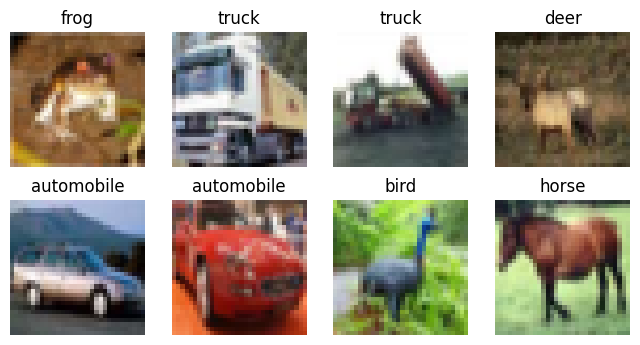

In [2]:
plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis('off')
plt.show()

In [3]:
cnn=models.Sequential([
    layers.Conv2D(32,3,activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history=cnn.fit(x_train,y_train,epochs=5,validation_split=.2)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 47ms/step - accuracy: 0.4608 - loss: 1.4966 - val_accuracy: 0.5702 - val_loss: 1.2239
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step - accuracy: 0.6021 - loss: 1.1307 - val_accuracy: 0.6221 - val_loss: 1.0699
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.6562 - loss: 0.9867 - val_accuracy: 0.6485 - val_loss: 0.9982
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.6891 - loss: 0.8900 - val_accuracy: 0.6643 - val_loss: 0.9727
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.7149 - loss: 0.8136 - val_accuracy: 0.6758 - val_loss: 0.9373


CNN Accuracy: 67.05999970436096 %


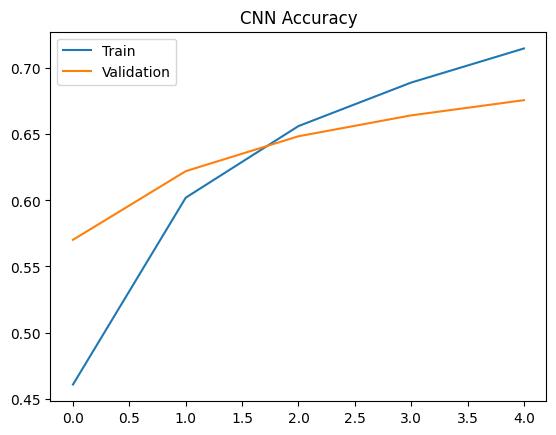

In [4]:
loss,acc=cnn.evaluate(x_test,y_test,verbose=0)
print("CNN Accuracy:",acc*100,"%")

plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title("CNN Accuracy")
plt.legend()
plt.show()

In [5]:
pred=np.argmax(cnn.predict(x_test),axis=1)

print(classification_report(
    y_test.flatten(),pred,target_names=classes
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step
              precision    recall  f1-score   support

    airplane       0.69      0.68      0.69      1000
  automobile       0.78      0.84      0.81      1000
        bird       0.58      0.52      0.55      1000
         cat       0.55      0.36      0.44      1000
        deer       0.59      0.66      0.62      1000
         dog       0.52      0.67      0.58      1000
        frog       0.72      0.79      0.75      1000
       horse       0.81      0.63      0.71      1000
        ship       0.71      0.83      0.77      1000
       truck       0.78      0.72      0.75      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000



In [6]:
x_train_vgg=tf.image.resize(x_train,(64,64))
x_test_vgg=tf.image.resize(x_test,(64,64))

In [ ]:
base=VGG16(weights='imagenet',include_top=False,input_shape=(64,64,3))
base.trainable=False

vgg=models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

vgg.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

history_vgg=vgg.fit(
    x_train_vgg,y_train,
    epochs=3,
    validation_split=.2
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2420s 2s/step - accuracy: 0.5468 - loss: 1.3127 - val_accuracy: 0.6090 - val_loss: 1.1332
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6209 - loss: 1.0918

In [ ]:
# Evaluate the VGG model and plot its performance
loss_vgg, acc_vgg = vgg.evaluate(x_test_vgg, y_test, verbose=0)
print("VGG16 Accuracy:", acc_vgg * 100, "%")

plt.figure(figsize=(8, 4))
plt.plot(history_vgg.history['accuracy'], label='Train')
plt.plot(history_vgg.history['val_accuracy'], label='Validation')
plt.title("VGG16 Accuracy")
plt.legend()
plt.show()